# Halos, halo finders, and the HOD

A hands-on companion to the lecture. You will:

1. build a **mock universe with known ground truth**, so every recovered mass can be graded;
2. run **friends-of-friends** and watch the catalogue change as you turn the linking length `b`;
3. see that a bridged FoF group is **two velocity streams**, and split it with a 6-D metric;
4. compare **spherical-overdensity masses at several thresholds** against FoF and against truth;
5. populate the catalogue with an **HOD** and measure the clustering it produces.

**Everything you are meant to change lives in the `P` dictionary in section 1.**
Edit it, re-run from section 2 down, watch what moves.

*Why a mock instead of a simulation?* The lesson here is about the **finder**, not the
dynamics. With a mock we know each halo's true mass, centre and particle membership, so
"b = 0.30 merged these two halos and overestimated the mass by 80%" becomes a number
instead of an impression. Every routine below works unchanged on a real snapshot — swap
in your own `pos`, `vel`, `M_P`, `L` at the end of section 2 and drop the ground-truth
comparisons.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.integrate import quad
from scipy.special import erf

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.labelsize": 12,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "legend.frameon": False,
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 2,
})
C_HALO, C_SAT, C_ALT, C_BG = "#D9531E", "#0E9E90", "#5B4A85", "#B9B4C9"
rng = np.random.default_rng(20260728)
T0 = time.time()
print("ready")

ready


## 1. The knob panel

Units throughout: mass in $h^{-1}M_\odot$, length in $h^{-1}$Mpc, velocity in km/s.

In [2]:
P = dict(
    # ---------------- box and resolution -------------------------------------
    L=50.0,          # box side
    n_side=64,       # particles per side; N = n_side**3, and this sets M_P
    n_min_halo=20,   # smallest halo we create, in particles

    # ---------------- cosmology ----------------------------------------------
    Om=0.31, Ob=0.048, h=0.674, ns=0.965, s8=0.81,

    # ---------------- mock structure -----------------------------------------
    f_filament=0.45,       # fraction of diffuse particles laid along filaments
    filament_width=0.35,   # filament thickness  <-- what FoF bridges across
    sigma_bulk=250.0,      # rms halo bulk velocity
    r_trunc=1.6,           # sample each NFW halo out to this multiple of R_200m

    # ---------------- the planted merging pair -------------------------------
    pair_mass=1.2e13,
    pair_sep_frac=1.15,    # centre separation as a multiple of (R_1 + R_2)
    pair_vrel=900.0,       # relative velocity along the separation axis

    # ---------------- friends-of-friends -------------------------------------
    b_scan=[0.10, 0.15, 0.20, 0.25, 0.30, 0.35],
    b_show=[0.15, 0.20, 0.30],   # the three we plot side by side
    b_main=0.20,                 # the catalogue carried into sections 5 and 6
    fof_min_n=20,                # discard groups smaller than this

    # ---------------- 6-D phase-space finder ---------------------------------
    link6_scan=[0.45, 0.60, 0.75, 0.95, 1.30],
    peak_radius=0.15,      # radius used to locate a group's density peak

    # ---------------- spherical overdensity ----------------------------------
    deltas=[("200m", 200, "mean"), ("200c", 200, "crit"), ("500c", 500, "crit")],

    # ---------------- HOD, Zheng et al. (2005) five-parameter form -----------
    logMmin=12.00, sigma_logM=0.25, logM0=12.00, logM1=13.20, alpha=1.00,
)

RHO_CRIT0 = 2.775e11          # h^2 Msun/Mpc^3 == h^-1 Msun / (h^-1 Mpc)^3
RHO_M = P["Om"] * RHO_CRIT0
GNEWT = 4.30091e-9            # Mpc Msun^-1 (km/s)^2 ; the h's cancel in G M / R

L = P["L"]
N_TOT = P["n_side"] ** 3
M_P = RHO_M * L ** 3 / N_TOT
D_BAR = L / P["n_side"]
M_MIN = P["n_min_halo"] * M_P

print(f"box              {L:.0f} h^-1 Mpc")
print(f"particles        {N_TOT:,}  ({P['n_side']}^3)")
print(f"particle mass    {M_P:.3e} h^-1 Msun")
print(f"mean spacing     d_bar = {D_BAR:.4f}  ->  b=0.2 links pairs within "
      f"{0.2 * D_BAR:.4f} h^-1 Mpc")
print(f"smallest halo    {M_MIN:.3e} ({P['n_min_halo']} particles)")

box              50 h^-1 Mpc
particles        262,144  (64^3)
particle mass    4.102e+10 h^-1 Msun
mean spacing     d_bar = 0.7812  ->  b=0.2 links pairs within 0.1562 h^-1 Mpc
smallest halo    8.204e+11 (20 particles)


## 2. Build the mock universe

Three ingredients:

* **halos** — masses from a Sheth-Tormen mass function, NFW profiles, isotropic
  internal velocities with $\sigma_{\rm 1D}=\sqrt{GM/2R}$;
* **filaments** — diffuse particles laid between neighbouring halos. These are what FoF
  bridges across, so `filament_width` is the knob to abuse first;
* **a planted merging pair** — two equal halos passing through each other, giving a
  guaranteed two-stream system for section 4.

Whatever mass the halos do not claim goes into the diffuse component, so the box holds
exactly $\rho_m L^3$ and `d_bar` means what it means in a real simulation.

In [3]:
# ---------- linear power spectrum: Eisenstein & Hu (1998) no-wiggle ----------
_om, _ob = P["Om"] * P["h"] ** 2, P["Ob"] * P["h"] ** 2
_theta = 2.7255 / 2.7


def transfer(k):
    """Transfer function, k in h/Mpc."""
    s = 44.5 * np.log(9.83 / _om) / np.sqrt(1 + 10 * _ob ** 0.75)
    ag = (1 - 0.328 * np.log(431 * _om) * (P["Ob"] / P["Om"])
          + 0.38 * np.log(22.3 * _om) * (P["Ob"] / P["Om"]) ** 2)
    geff = P["Om"] * P["h"] * (ag + (1 - ag) / (1 + (0.43 * k * P["h"] * s) ** 4))
    q = k * _theta ** 2 / geff
    L0 = np.log(2 * np.e + 1.8 * q)
    return L0 / (L0 + (14.2 + 731.0 / (1 + 62.5 * q)) * q * q)


def _sigma(R, A=1.0):
    def f(lnk):
        k = np.exp(lnk)
        w = 3 * (np.sin(k * R) - k * R * np.cos(k * R)) / (k * R) ** 3
        return A * k ** P["ns"] * transfer(k) ** 2 * w ** 2 * k ** 3 / (2 * np.pi ** 2)
    return np.sqrt(quad(f, np.log(1e-4), np.log(3e2), limit=200)[0])


A_NORM = (P["s8"] / _sigma(8.0)) ** 2


def dndlnM(M):
    """Sheth-Tormen comoving number density per unit ln M."""
    M = np.atleast_1d(M).astype(float)
    R = (3 * M / (4 * np.pi * RHO_M)) ** (1 / 3)
    sig = np.array([_sigma(r, A_NORM) for r in R])
    nu = 1.686 / sig
    a, p, An = 0.707, 0.3, 0.3222
    f = (An * np.sqrt(2 * a / np.pi) * (1 + (1 / (a * nu ** 2)) ** p)
         * nu * np.exp(-a * nu ** 2 / 2))
    return (RHO_M / M) * f * (-np.gradient(np.log(sig), np.log(M)))


_grid = np.geomspace(M_MIN, 5e14, 400)
_cum = np.cumsum(dndlnM(_grid) * np.gradient(np.log(_grid)))
n_exp = _cum[-1] * L ** 3
n_halo = rng.poisson(n_exp)
M_true = np.interp(rng.uniform(0, 1, n_halo), _cum / _cum[-1], _grid)
M_true = np.sort(M_true)[::-1]

print(f"expected halos above {M_MIN:.2e}: {n_exp:.0f}    drawn: {n_halo}")
print(f"mass range      {M_true.min():.2e} .. {M_true.max():.2e}")
print(f"halo mass       {M_true.sum() / (RHO_M * L ** 3):.3f} of the box mass")

expected halos above 8.20e+11: 639    drawn: 646
mass range      8.20e+11 .. 1.84e+14
halo mass       0.270 of the box mass


In [4]:
def R_200m(M):
    return (3 * M / (4 * np.pi * 200 * RHO_M)) ** (1 / 3)


def conc(M):
    """Approximate c_200(M): mildly declining with mass."""
    return 5.5 * (M / 1e13) ** -0.10


def _mu(y):
    return np.log1p(y) - y / (1 + y)


def sample_nfw(n, R, c, r_max_frac):
    """n radii from an NFW profile inside r_max_frac * R, with isotropic angles."""
    x = np.geomspace(1e-4, r_max_frac, 900)
    cdf = _mu(c * x) / _mu(c * r_max_frac)
    r = np.interp(rng.uniform(0, 1, n), cdf, x) * R
    mu_ = rng.uniform(-1, 1, n)
    phi = rng.uniform(0, 2 * np.pi, n)
    st = np.sqrt(1 - mu_ ** 2)
    return np.stack([r * st * np.cos(phi), r * st * np.sin(phi), r * mu_], 1)


def make_halo(M, centre, vbulk):
    """(positions, velocities, n_particles) for one halo of mass M = M_200m."""
    R, c = R_200m(M), conc(M)
    n = max(int(round(M * _mu(c * P["r_trunc"]) / _mu(c) / M_P)), 4)
    sig1d = np.sqrt(GNEWT * M / (2 * R))
    return (centre + sample_nfw(n, R, c, P["r_trunc"]),
            vbulk + rng.standard_normal((n, 3)) * sig1d, n)


# ---------- place halos, clustered around a set of nodes ---------------------
n_node = max(int(0.20 * n_halo), 8)
nodes = rng.uniform(0, L, (n_node, 3))
cen = np.empty((n_halo, 3))
cen[:n_node] = nodes
for i in range(n_node, n_halo):
    cen[i] = nodes[rng.integers(n_node)] + rng.standard_normal(3) * 3.0
cen %= L
vbulk = rng.standard_normal((n_halo, 3)) * P["sigma_bulk"]

# ---------- plant the merging pair at the box centre -------------------------
Rp = R_200m(P["pair_mass"])
sep = P["pair_sep_frac"] * 2 * Rp
pair_mid = np.full(3, 0.5 * L)
axis = np.array([1.0, 0.25, 0.0])
axis /= np.linalg.norm(axis)
M_true = np.concatenate([M_true, [P["pair_mass"]] * 2])
cen = np.vstack([cen, pair_mid - 0.5 * sep * axis, pair_mid + 0.5 * sep * axis])
vbulk = np.vstack([vbulk, +0.5 * P["pair_vrel"] * axis,
                   -0.5 * P["pair_vrel"] * axis])
PAIR_IDS = np.array([len(M_true) - 2, len(M_true) - 1])
n_halo = len(M_true)

pos_l, vel_l, hid_l = [], [], []
for i in range(n_halo):
    p_, v_, n_ = make_halo(M_true[i], cen[i], vbulk[i])
    pos_l.append(p_); vel_l.append(v_); hid_l.append(np.full(n_, i))
pos_h, vel_h = np.concatenate(pos_l) % L, np.concatenate(vel_l)
hid_h = np.concatenate(hid_l)
n_part_true = np.bincount(hid_h, minlength=n_halo)
print(f"halo particles   {len(pos_h):,}  of {N_TOT:,}")
print(f"pair separation  {sep:.3f} h^-1 Mpc   (each R_200m = {Rp:.3f})")

halo particles   96,559  of 262,144
pair separation  1.265 h^-1 Mpc   (each R_200m = 0.550)


In [5]:
# ---------- diffuse component: filaments plus a uniform floor ---------------
n_diffuse = max(N_TOT - len(pos_h), 1000)
n_fil = int(P["f_filament"] * n_diffuse)
n_uni = n_diffuse - n_fil

_, nn = cKDTree(cen, boxsize=L).query(cen, k=2)     # each halo's nearest neighbour
d_vec = cen[nn[:, 1]] - cen
d_vec -= L * np.round(d_vec / L)                    # minimum image
seg = np.linalg.norm(d_vec, axis=1)
pick = rng.choice(n_halo, size=n_fil, p=seg / seg.sum())
pos_f = (cen[pick] + rng.uniform(0, 1, n_fil)[:, None] * d_vec[pick]
         + rng.standard_normal((n_fil, 3)) * P["filament_width"])
vel_f = vbulk[pick] + rng.standard_normal((n_fil, 3)) * 180.0

pos = np.vstack([pos_h, pos_f, rng.uniform(0, L, (n_uni, 3))]) % L
vel = np.vstack([vel_h, vel_f, rng.standard_normal((n_uni, 3)) * 150.0])
hid = np.concatenate([hid_h, np.full(n_fil + n_uni, -1)])   # -1 = in no halo
N = len(pos)
print(f"total particles  {N:,}   (halo {len(pos_h):,} | filament {n_fil:,} | "
      f"uniform {n_uni:,})")
print(f"in-halo fraction {(hid >= 0).mean():.3f}")
print(f"[{time.time() - T0:.1f} s]")

total particles  262,144   (halo 96,559 | filament 74,513 | uniform 91,072)
in-halo fraction 0.368
[6.2 s]


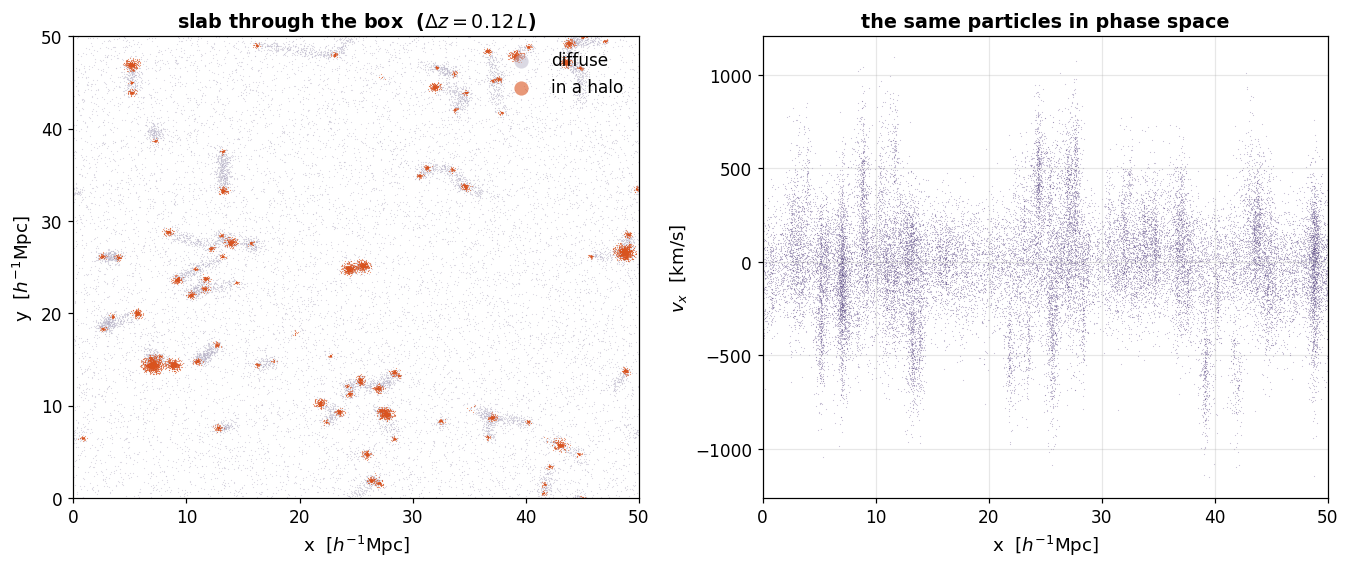

In [6]:
sl = (pos[:, 2] > 0.44 * L) & (pos[:, 2] < 0.56 * L)
fig, ax = plt.subplots(1, 2, figsize=(12.4, 5.3))
ax[0].scatter(pos[sl & (hid < 0), 0], pos[sl & (hid < 0), 1], s=0.6, c=C_BG,
              alpha=0.5, lw=0, label="diffuse")
ax[0].scatter(pos[sl & (hid >= 0), 0], pos[sl & (hid >= 0), 1], s=0.6, c=C_HALO,
              alpha=0.6, lw=0, label="in a halo")
ax[0].set(xlabel="x  [$h^{-1}$Mpc]", ylabel="y  [$h^{-1}$Mpc]", xlim=(0, L),
          ylim=(0, L), title="slab through the box  ($\\Delta z = 0.12\\,L$)")
ax[0].legend(markerscale=12, loc="upper right")
ax[0].grid(False)
ax[1].scatter(pos[sl, 0], vel[sl, 0], s=0.6, c=C_ALT, alpha=0.35, lw=0)
ax[1].set(xlabel="x  [$h^{-1}$Mpc]", ylabel="$v_x$  [km/s]", xlim=(0, L),
          title="the same particles in phase space")
fig.tight_layout()
plt.show()

The right panel is section 4 in miniature. The vertical smears are halos, and their
**width in velocity** is information a position-only finder never looks at.

## 3. Friends-of-friends

The whole algorithm: link every pair closer than $b\,\bar d$, take connected components.
Two lines of real work and one free parameter.

In [7]:
def run_fof(pos, b, L, d_bar, min_n=20):
    """Periodic FoF. Returns labels, with -1 for particles in no surviving group."""
    tree = cKDTree(pos, boxsize=L)
    pairs = tree.query_pairs(b * d_bar, output_type="ndarray")
    g = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])),
                   shape=(len(pos),) * 2)
    ncomp, lab = connected_components(g, directed=False)
    size = np.bincount(lab, minlength=ncomp)
    keep = size >= min_n
    remap = np.full(ncomp, -1)
    remap[keep] = np.arange(keep.sum())
    return remap[lab]


def group_props(pos, vel, lab, L, m_p, peak_radius=0.15):
    """Vectorised per-group mass, mean position, mean velocity, and density peak."""
    m = lab >= 0
    ng = int(lab.max()) + 1
    o = np.argsort(lab[m], kind="stable")
    gs, ps, vs = lab[m][o], pos[m][o], vel[m][o]
    ug, start, cnt = np.unique(gs, return_index=True, return_counts=True)
    anchor = ps[start]
    d = ps - np.repeat(anchor, cnt, axis=0)
    d -= L * np.round(d / L)                       # unwrap within each group
    M = np.zeros(ng)
    ctr = np.zeros((ng, 3)); vbar = np.zeros((ng, 3)); peak = np.zeros((ng, 3))
    M[ug] = cnt * m_p
    ctr[ug] = (anchor + np.add.reduceat(d, start, axis=0) / cnt[:, None]) % L
    vbar[ug] = np.add.reduceat(vs, start, axis=0) / cnt[:, None]
    for k, gi in enumerate(ug):                    # densest member = better centre
        dd = d[start[k]:start[k] + cnt[k]]
        nnb = cKDTree(dd).query_ball_point(dd, peak_radius, return_length=True)
        peak[gi] = (anchor[k] + dd[np.argmax(nnb)]) % L
    return M, ctr, vbar, peak


def group_truth(lab, hid, n_halo, n_part_true):
    """Per group: purity, dominant true halo, particles matched, halos swallowed."""
    ng = int(lab.max()) + 1
    m = (lab >= 0) & (hid >= 0)
    g = lab[m].astype(np.int64)
    h = hid[m].astype(np.int64)
    uk, cnt = np.unique(g * n_halo + h, return_counts=True)
    ug = (uk // n_halo).astype(int)
    uh = (uk % n_halo).astype(int)
    top = np.zeros(ng); tot = np.zeros(ng); nswal = np.zeros(ng)
    np.maximum.at(top, ug, cnt)
    np.add.at(tot, ug, cnt)
    np.add.at(nswal, ug, (cnt >= 0.5 * n_part_true[uh]).astype(float))
    dom = np.full(ng, -1)
    order = np.lexsort((cnt, ug))                  # last write per group = largest
    dom[ug[order]] = uh[order]
    with np.errstate(invalid="ignore"):
        pur = np.where(tot > 0, top / np.maximum(tot, 1), np.nan)
    return pur, dom, tot, nswal

In [8]:
rows, labels_by_b = [], {}
for b in P["b_scan"]:
    lab = run_fof(pos, b, L, D_BAR, P["fof_min_n"])
    labels_by_b[b] = lab
    pur, dom, tot, nswal = group_truth(lab, hid, n_halo, n_part_true)
    rows.append(dict(b=b, ng=int(lab.max()) + 1,
                     Mmax=np.bincount(lab[lab >= 0]).max() * M_P,
                     flink=(lab >= 0).mean(), pur=np.nanmedian(pur),
                     pur10=np.nanpercentile(pur, 10),
                     nblend=int((nswal >= 2).sum())))

print(f"{'b':>6} {'groups':>7} {'M_largest':>11} {'f linked':>9} "
      f"{'purity':>8} {'p10':>6} {'blended':>8}")
print("-" * 60)
for r in rows:
    print(f"{r['b']:6.2f} {r['ng']:7d} {r['Mmax']:11.3e} {r['flink']:9.3f} "
          f"{r['pur']:8.2f} {r['pur10']:6.2f} {r['nblend']:8d}")
print("\npurity  = fraction of a group's halo particles from its dominant true halo")
print("          the MEDIAN stays at 1.00 because most groups are isolated halos;")
print("          the 10th percentile (p10) is where blending shows up")
print("blended = groups that swallowed at least half of 2+ different true halos")
print(f"[{time.time() - T0:.1f} s]")

     b  groups   M_largest  f linked   purity    p10  blended
------------------------------------------------------------
  0.10     449   7.535e+13     0.133     1.00   1.00        0
  0.15     612   1.304e+14     0.229     1.00   1.00        4
  0.20     649   1.753e+14     0.317     1.00   1.00       10
  0.25     696   2.145e+14     0.412     1.00   1.00       27
  0.30     608   2.691e+14     0.503     1.00   0.70      115
  0.35     521   3.076e+14     0.572     1.00   0.56      176

purity  = fraction of a group's halo particles from its dominant true halo
          the MEDIAN stays at 1.00 because most groups are isolated halos;
          the 10th percentile (p10) is where blending shows up
blended = groups that swallowed at least half of 2+ different true halos
[31.6 s]


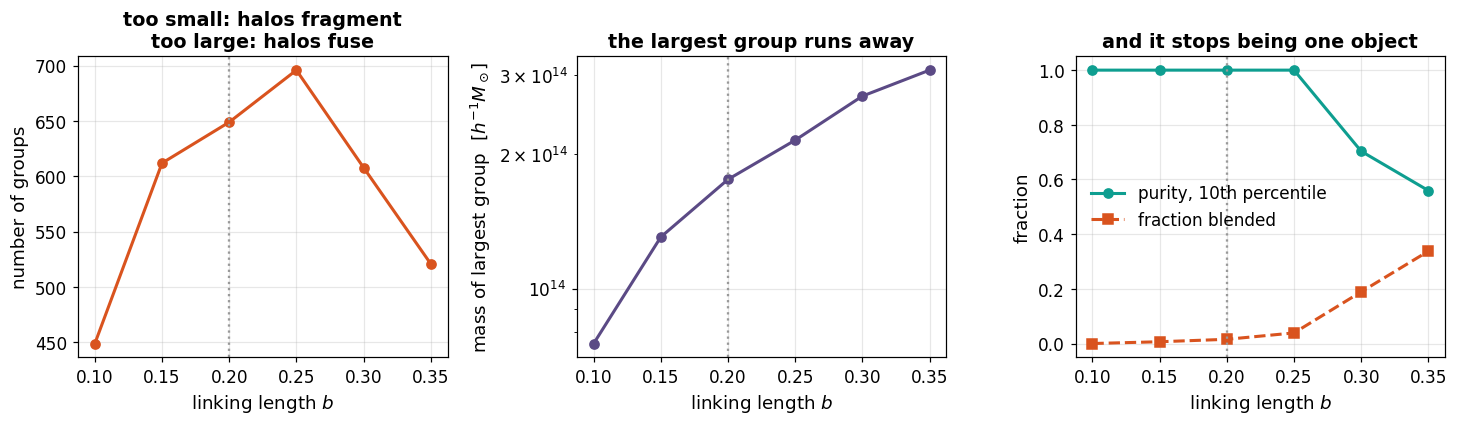

In [9]:
bb = np.array([r["b"] for r in rows])
fig, ax = plt.subplots(1, 3, figsize=(13.4, 4.0))
ax[0].plot(bb, [r["ng"] for r in rows], "o-", color=C_HALO)
ax[0].set(xlabel="linking length $b$", ylabel="number of groups",
          title="too small: halos fragment\ntoo large: halos fuse")
ax[1].semilogy(bb, [r["Mmax"] for r in rows], "o-", color=C_ALT)
ax[1].set(xlabel="linking length $b$",
          ylabel="mass of largest group  [$h^{-1}M_\\odot$]",
          title="the largest group runs away")
ax[2].plot(bb, [r["pur10"] for r in rows], "o-", color=C_SAT,
           label="purity, 10th percentile")
ax[2].plot(bb, [r["nblend"] / max(r["ng"], 1) for r in rows], "s--", color=C_HALO,
           label="fraction blended")
ax[2].set(xlabel="linking length $b$", ylabel="fraction",
          title="and it stops being one object")
ax[2].legend()
for a in ax:
    a.axvline(0.2, color="0.6", ls=":", lw=1.5)
fig.tight_layout()
plt.show()

The dotted line is the conventional $b = 0.2$. Nothing distinguishes it in any of these
curves. It is a convention — chosen because for typical concentrations it lands near a
spherical overdensity of a few hundred — not a threshold the physics hands you.

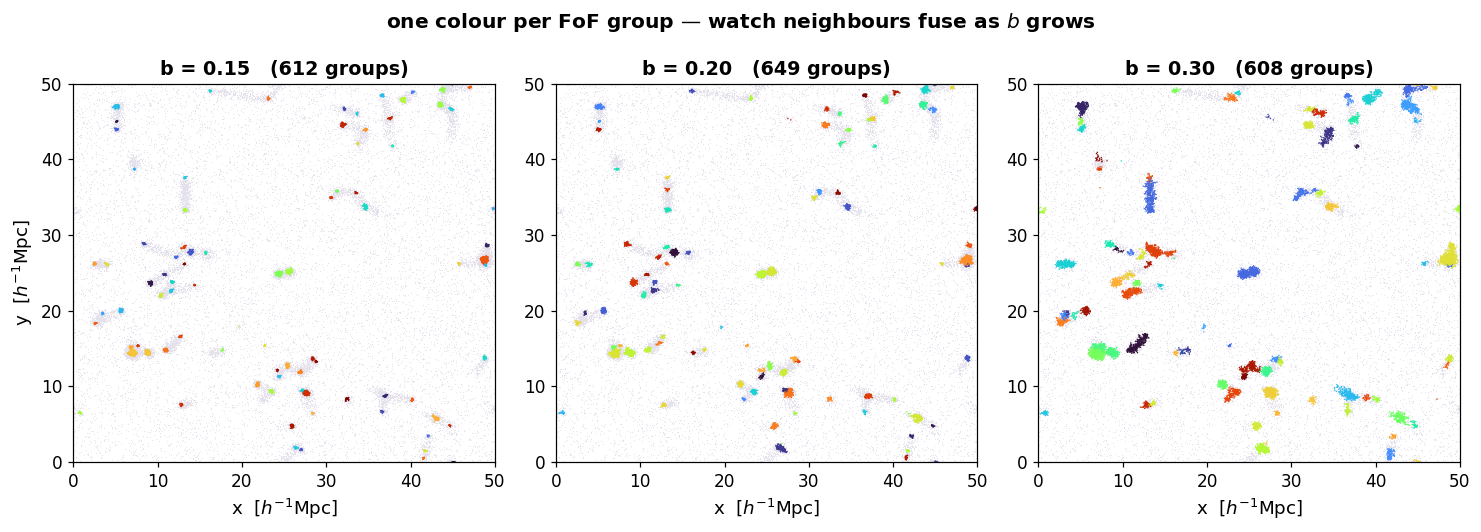

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(13.6, 4.9))
for a, b in zip(ax, P["b_show"]):
    lab = labels_by_b[b]
    s = sl & (lab >= 0)
    a.scatter(pos[sl & (lab < 0), 0], pos[sl & (lab < 0), 1], s=0.5, c="#E4E1EC", lw=0)
    a.scatter(pos[s, 0], pos[s, 1], s=0.9, lw=0, cmap="turbo",
              c=(lab[s] * 2654435761 % 977) / 977.0)
    a.set(title=f"b = {b:.2f}   ({int(lab.max()) + 1} groups)", xlim=(0, L),
          ylim=(0, L), xlabel="x  [$h^{-1}$Mpc]")
    a.grid(False)
ax[0].set_ylabel("y  [$h^{-1}$Mpc]")
fig.suptitle("one colour per FoF group — watch neighbours fuse as $b$ grows",
             fontweight="bold")
fig.tight_layout()
plt.show()

### The planted pair: where bridging actually bites

Two $1.2\times10^{13}$ halos, centres 1.15 $(R_1+R_2)$ apart, passing through each
other at 900 km/s. Count the groups at their location as `b` grows.

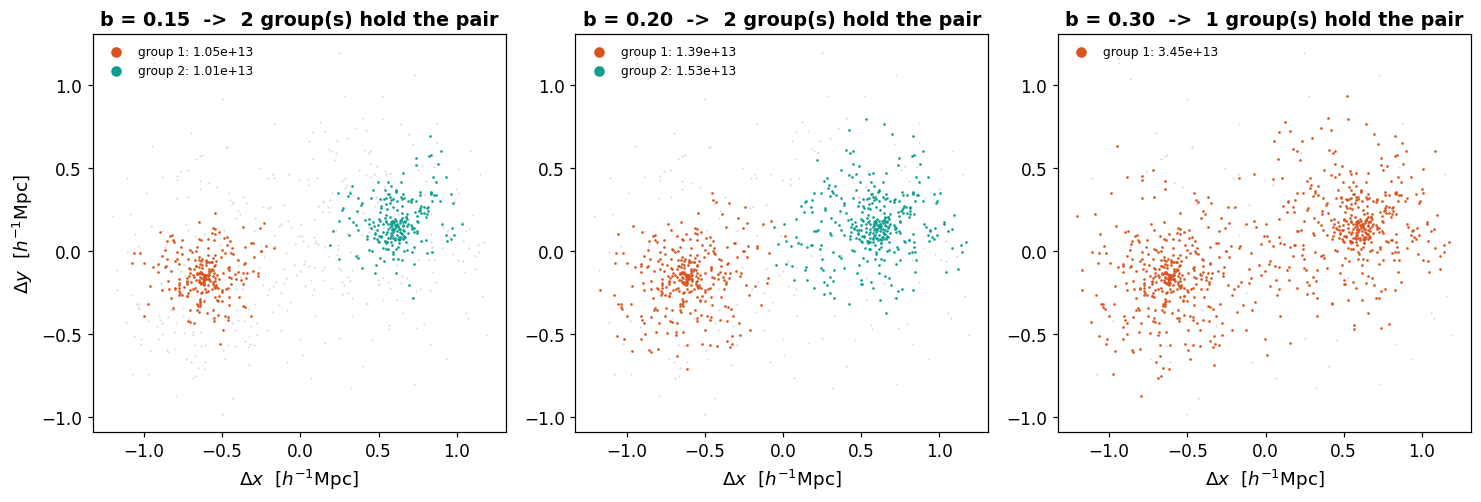

true mass of each planted halo : 1.200e+13
true combined mass             : 2.400e+13
  b = 0.10  ->  2 group(s) hold the pair
  b = 0.15  ->  2 group(s) hold the pair
  b = 0.20  ->  2 group(s) hold the pair
  b = 0.25  ->  1 group(s) hold the pair
  b = 0.30  ->  1 group(s) hold the pair
  b = 0.35  ->  1 group(s) hold the pair


In [11]:
def groups_at_pair(b):
    """Distinct FoF groups holding the planted pair's particles (ignoring -1)."""
    lab = labels_by_b[b] if b in labels_by_b else run_fof(
        pos, b, L, D_BAR, P["fof_min_n"])
    g = lab[(hid == PAIR_IDS[0]) | (hid == PAIR_IDS[1])]
    return np.unique(g[g >= 0])


fig, ax = plt.subplots(1, 3, figsize=(13.6, 4.7))
for a, b in zip(ax, [0.15, 0.20, 0.30]):
    lab = labels_by_b[b]
    d = pos - pair_mid
    d -= L * np.round(d / L)
    m = (np.abs(d) < 2.2 * Rp).all(1)
    ids = groups_at_pair(b)
    a.scatter(d[m & (lab < 0), 0], d[m & (lab < 0), 1], s=2, c="#DCD8E6", lw=0)
    for k, g in enumerate(ids):
        mm = m & (lab == g)
        a.scatter(d[mm, 0], d[mm, 1], s=3, lw=0,
                  c=[C_HALO, C_SAT, C_ALT, "#C9A227"][k % 4],
                  label=f"group {k + 1}: {(lab == g).sum() * M_P:.2e}")
    a.set(title=f"b = {b:.2f}  ->  {len(ids)} group(s) hold the pair",
          xlabel="$\\Delta x$  [$h^{-1}$Mpc]")
    a.legend(fontsize=8, markerscale=4, loc="upper left")
    a.grid(False)
ax[0].set_ylabel("$\\Delta y$  [$h^{-1}$Mpc]")
fig.tight_layout()
plt.show()

print(f"true mass of each planted halo : {P['pair_mass']:.3e}")
print(f"true combined mass             : {2 * P['pair_mass']:.3e}")
for b in P["b_scan"]:
    print(f"  b = {b:.2f}  ->  {len(groups_at_pair(b))} group(s) hold the pair")

## 4. The bridged group is two velocity streams

Take the FoF group holding the pair at the largest `b` and look at it in phase space.
In position it is one object. In velocity it never was.

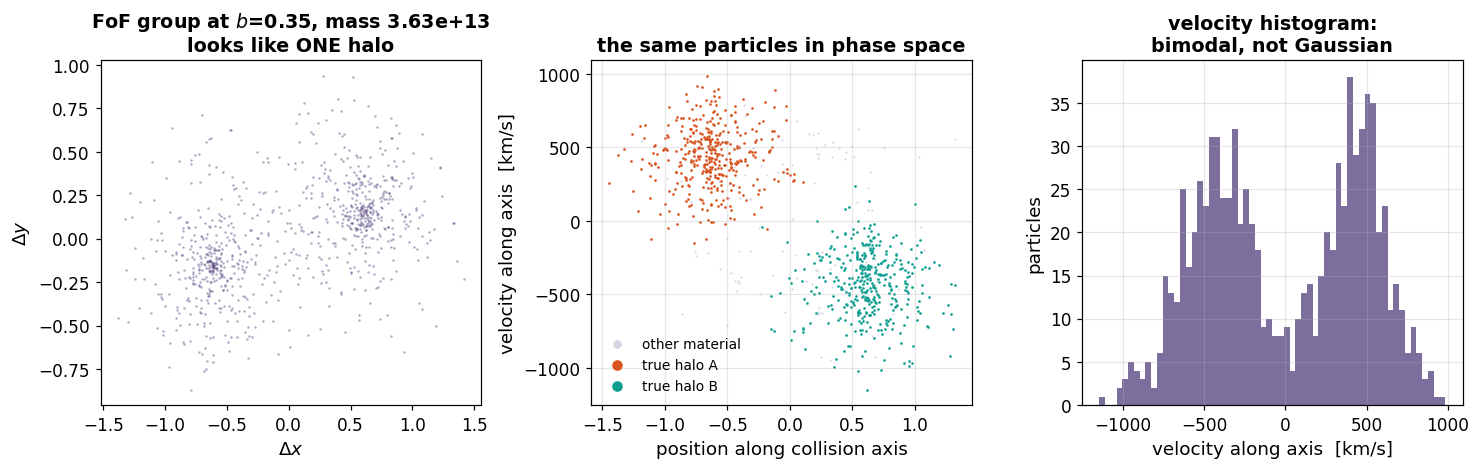

internal 1-D dispersion of each halo :    216.6 km/s
relative bulk velocity               :    900.0 km/s
separation in units of sigma         :     4.16   (above ~2 means cleanly separable)


In [12]:
b_merge = max(P["b_scan"])
lab_m = labels_by_b[b_merge]
_g = lab_m[(hid == PAIR_IDS[0]) & (lab_m >= 0)]
g_pair = np.bincount(_g).argmax()
sel = lab_m == g_pair
d = pos[sel] - pair_mid
d -= L * np.round(d / L)
proj, vlos = d @ axis, vel[sel] @ axis
which = hid[sel]
is1, is2 = which == PAIR_IDS[0], which == PAIR_IDS[1]

fig, ax = plt.subplots(1, 3, figsize=(13.6, 4.4))
ax[0].scatter(d[:, 0], d[:, 1], s=2.5, c=C_ALT, alpha=0.5, lw=0)
ax[0].set(xlabel="$\\Delta x$", ylabel="$\\Delta y$",
          title=f"FoF group at $b$={b_merge:.2f}, mass {sel.sum() * M_P:.2e}\n"
                f"looks like ONE halo")
ax[0].grid(False)
ax[1].scatter(proj[~(is1 | is2)], vlos[~(is1 | is2)], s=2, c="#D8D4E4", lw=0,
              label="other material")
ax[1].scatter(proj[is1], vlos[is1], s=3, c=C_HALO, lw=0, label="true halo A")
ax[1].scatter(proj[is2], vlos[is2], s=3, c=C_SAT, lw=0, label="true halo B")
ax[1].set(xlabel="position along collision axis",
          ylabel="velocity along axis  [km/s]",
          title="the same particles in phase space")
ax[1].legend(markerscale=4, fontsize=9)
ax[2].hist(vlos, bins=60, color=C_ALT, alpha=0.8)
ax[2].set(xlabel="velocity along axis  [km/s]", ylabel="particles",
          title="velocity histogram:\nbimodal, not Gaussian")
fig.tight_layout()
plt.show()

sig_int = np.sqrt(GNEWT * P["pair_mass"] / (2 * Rp))
print(f"internal 1-D dispersion of each halo : {sig_int:8.1f} km/s")
print(f"relative bulk velocity               : {P['pair_vrel']:8.1f} km/s")
print(f"separation in units of sigma         : {P['pair_vrel'] / sig_int:8.2f}"
      f"   (above ~2 means cleanly separable)")

### A 6-D linking length splits what 3-D cannot

The ROCKSTAR idea in ten lines: rescale positions and velocities by **this group's own**
dispersions so that
$d^2 = |\Delta x|^2/\sigma_x^2 + |\Delta v|^2/\sigma_v^2$
is dimensionless, then run the same FoF in six dimensions. No universal
km/s-per-Mpc conversion is imposed anywhere.

In [13]:
def fof6d(dx, dv, link, min_n=40):
    """FoF in the group's own normalised 6-D phase space."""
    X = np.hstack([dx / dx.std(), dv / dv.std()])
    tree = cKDTree(X)
    pairs = tree.query_pairs(link, output_type="ndarray")
    g = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])),
                   shape=(len(X),) * 2)
    nc, lab = connected_components(g, directed=False)
    size = np.bincount(lab, minlength=nc)
    keep = size >= min_n
    remap = np.full(nc, -1)
    remap[keep] = np.arange(keep.sum())
    return remap[lab]


dv6 = vel[sel] - vel[sel].mean(0)
print(f"{'6-D link':>9} {'subgroups':>10} {'2 biggest':>16} "
      f"{'their halo-A fraction':>24}")
print("-" * 64)
for link in P["link6_scan"]:
    l6 = fof6d(d, dv6, link, min_n=40)
    ng6 = int(l6.max()) + 1
    if ng6 == 0:
        print(f"{link:9.2f} {0:10d} {'(all too small)':>16} {'-':>24}")
        continue
    size6 = np.bincount(l6[l6 >= 0], minlength=ng6)
    big = np.argsort(-size6)[:2]
    fa = [round(float((which[l6 == g] == PAIR_IDS[0]).mean()), 2) for g in big]
    sz = ", ".join(str(int(v)) for v in size6[big])
    fr = ", ".join(f"{v:.2f}" for v in fa)
    print(f"{link:9.2f} {ng6:10d} {sz:>16} {fr:>24}")
print("\nA clean split = two comparable subgroups with fractions near 1.0 and 0.0.")
print("Too small a 6-D link fragments everything below min_n; too large re-merges.")
print("For comparison, 3-D FoF holds the pair in:")
for b in P["b_scan"]:
    print(f"   b = {b:.2f}  ->  {len(groups_at_pair(b))} group(s)")

 6-D link  subgroups        2 biggest    their halo-A fraction
----------------------------------------------------------------
     0.45          0  (all too small)                        -
     0.60          2         137, 122               0.00, 1.00
     0.75          2         248, 248               0.95, 0.00
     0.95          1              723                     0.46
     1.30          1              868                     0.44

A clean split = two comparable subgroups with fractions near 1.0 and 0.0.
Too small a 6-D link fragments everything below min_n; too large re-merges.
For comparison, 3-D FoF holds the pair in:
   b = 0.10  ->  2 group(s)
   b = 0.15  ->  2 group(s)
   b = 0.20  ->  2 group(s)
   b = 0.25  ->  1 group(s)
   b = 0.30  ->  1 group(s)
   b = 0.35  ->  1 group(s)


## 5. Spherical overdensity at several thresholds

Grow a sphere from a centre until the **mean enclosed** density falls to
$\Delta\rho_{\rm ref}$. Two things you must declare: the value of $\Delta$, and whether
$\rho_{\rm ref}$ is the critical or the mean matter density. We also try two different
centres, because the centre is a choice too.

In [14]:
TREE = cKDTree(pos, boxsize=L)


def so_mass(centre, Delta, ref="mean", M_guess=1e13, n_floor=10):
    """(M_Delta, R_Delta) at the first outward crossing of the threshold."""
    rho_ref = RHO_M if ref == "mean" else RHO_CRIT0
    r_max = max(4.0 * R_200m(max(M_guess, 1e11)), 0.8)
    idx = TREE.query_ball_point(centre, r_max)
    if len(idx) < n_floor:
        return 0.0, 0.0
    dd = pos[idx] - centre
    dd -= L * np.round(dd / L)
    r = np.sort(np.linalg.norm(dd, axis=1))
    r = r[r > 1e-6]
    if len(r) < n_floor:
        return 0.0, 0.0
    Menc = np.arange(1, len(r) + 1) * M_P
    rho_bar = Menc / (4 / 3 * np.pi * r ** 3)
    below = np.where(rho_bar[n_floor:] < Delta * rho_ref)[0]
    if len(below) == 0:
        return Menc[-1], r[-1]                     # never drops: r_max too small
    i = below[0] + n_floor - 1
    return Menc[i], r[i]


lab_main = labels_by_b[P["b_main"]]
M_fof, ctr_mean, v_fof, ctr_peak = group_props(
    pos, vel, lab_main, L, M_P, P["peak_radius"])
print(f"FoF catalogue at b = {P['b_main']}: {len(M_fof)} groups, "
      f"{M_fof.min():.2e} .. {M_fof.max():.2e}")

so = {}
for name, Delta, ref in P["deltas"]:
    for tag, ctr in [("peak", ctr_peak), ("mean", ctr_mean)]:
        out = np.array([so_mass(c, Delta, ref, M_guess=mg)
                        for c, mg in zip(ctr, M_fof)])
        so[(name, tag)] = dict(M=out[:, 0], R=out[:, 1])
    g = so[(name, "peak")]["M"] > 0
    print(f"  M_{name:<5s} (density-peak centre)  median / M_FoF = "
          f"{np.median(so[(name, 'peak')]['M'][g] / M_fof[g]):.3f}")
print(f"[{time.time() - T0:.1f} s]")

FoF catalogue at b = 0.2: 649 groups, 8.20e+11 .. 1.75e+14
  M_200m  (density-peak centre)  median / M_FoF = 0.875
  M_200c  (density-peak centre)  median / M_FoF = 0.562
  M_500c  (density-peak centre)  median / M_FoF = 0.353
[170.0 s]


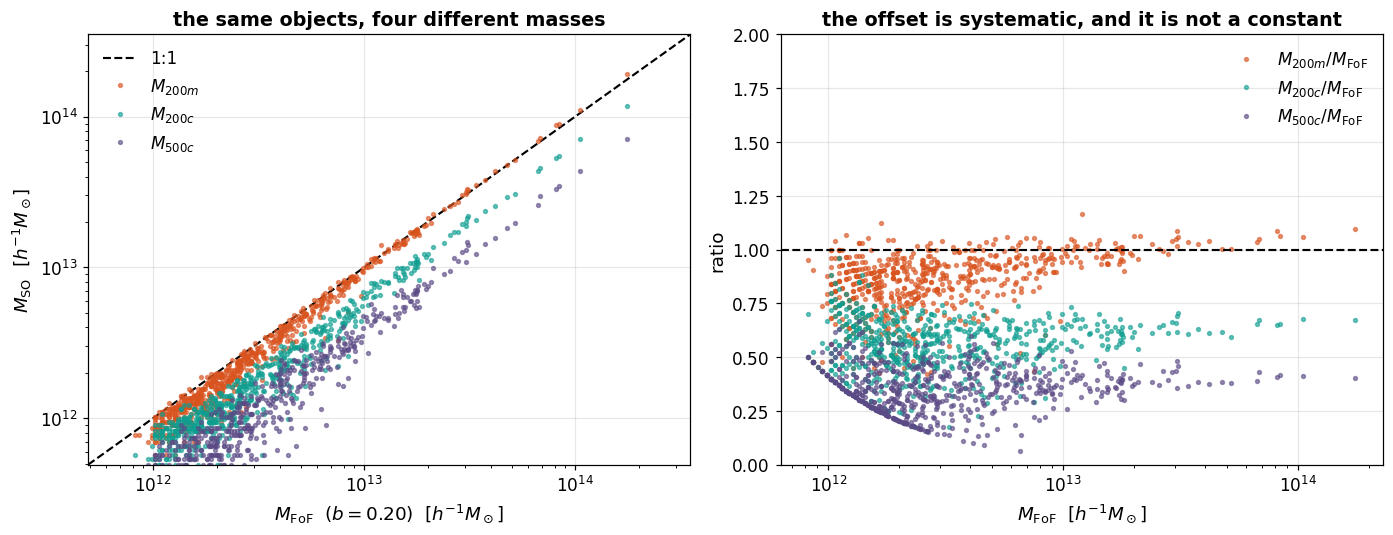

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 5.0))
lo, hi = 0.6 * M_fof.min(), 2.0 * M_fof.max()
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1.4, label="1:1")
for (name, _, _), col in zip(P["deltas"], [C_HALO, C_SAT, C_ALT]):
    g = so[(name, "peak")]["M"] > 0
    ax[0].loglog(M_fof[g], so[(name, "peak")]["M"][g], ".", ms=5, alpha=0.6,
                 color=col, label=f"$M_{{{name}}}$")
ax[0].set(xlabel=f"$M_{{\\rm FoF}}$  ($b = {P['b_main']:.2f}$)  [$h^{{-1}}M_\\odot$]",
          ylabel="$M_{\\rm SO}$  [$h^{-1}M_\\odot$]", xlim=(lo, hi), ylim=(lo, hi),
          title="the same objects, four different masses")
ax[0].legend(loc="upper left")
for (name, _, _), col in zip(P["deltas"], [C_HALO, C_SAT, C_ALT]):
    g = so[(name, "peak")]["M"] > 0
    ax[1].semilogx(M_fof[g], so[(name, "peak")]["M"][g] / M_fof[g], ".", ms=5,
                   alpha=0.6, color=col, label=f"$M_{{{name}}}/M_{{\\rm FoF}}$")
ax[1].axhline(1, color="k", ls="--", lw=1.4)
ax[1].set(xlabel="$M_{\\rm FoF}$  [$h^{-1}M_\\odot$]", ylabel="ratio", ylim=(0, 2.0),
          title="the offset is systematic, and it is not a constant")
ax[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

Read the ordering off the plot: at $z = 0$ the same halo has
$M_{\rm 200m} > M_{\rm 200c} > M_{\rm 500c}$, because a lower threshold puts the
boundary further out. The scatter against $M_{\rm FoF}$ is not noise — it tracks
concentration, which is why no universal FoF-to-SO conversion exists.

### Grading the estimators against the truth

`M_true` is $M_{\rm 200m}$ by construction, so a well-behaved $M_{\rm 200m}$ estimator
should return a median ratio near 1.

Expect $M_{\rm FoF}$ to sit **above** the truth: we populate each halo out to
$1.6\,R_{\rm 200m}$ (`r_trunc`) and FoF happily collects that outskirt material plus any
filament particles it can reach. The lesson is not the size of the offset but that it is
systematic, and that it moves when you change `b`, `r_trunc` or `filament_width`.

In [16]:
pur, dom, tot, nswal = group_truth(lab_main, hid, n_halo, n_part_true)
ok = (dom >= 0) & (pur > 0.5)
Mt = M_true[dom[ok]]
print(f"matched groups: {ok.sum()} of {len(M_fof)}  "
      f"(purity > 0.5 with a dominant true halo)")
print(f"\n{'estimator':>24} {'median M/M_true':>16} {'scatter (dex)':>14} {'used':>6}")
print("-" * 64)
cands = [("M_FoF", M_fof[ok])]
for name, _, _ in P["deltas"]:
    for tag in ("peak", "mean"):
        cands.append((f"M_{name} ({tag} centre)", so[(name, tag)]["M"][ok]))
for nm, arr in cands:
    g = arr > 0
    r = arr[g] / Mt[g]
    print(f"{nm:>24} {np.median(r):16.3f} {np.std(np.log10(r)):14.3f} {g.sum():6d}")
print("\nThe two centre choices give different masses for the same halos:")
print("that is the 'a different centre gives a different mass' slide, quantified.")

matched groups: 641 of 649  (purity > 0.5 with a dominant true halo)

               estimator  median M/M_true  scatter (dex)   used
----------------------------------------------------------------
                   M_FoF            1.273          0.172    641
    M_200m (peak centre)            1.105          0.185    641
    M_200m (mean centre)            1.170          0.190    641
    M_200c (peak centre)            0.713          0.180    641
    M_200c (mean centre)            0.731          0.197    641
    M_500c (peak centre)            0.449          0.183    641
    M_500c (mean centre)            0.455          0.194    641

The two centre choices give different masses for the same halos:
that is the 'a different centre gives a different mass' slide, quantified.


## 6. Populating the halos: the HOD

Zheng et al. (2005), five parameters:

$$\langle N_{\rm cen}|M\rangle=\tfrac12\left[1+\mathrm{erf}\!\left(\frac{\log M-\log M_{\min}}{\sigma_{\log M}}\right)\right],
\qquad
\langle N_{\rm sat}|M\rangle=\langle N_{\rm cen}|M\rangle\left(\frac{M-M_0}{M_1}\right)^{\alpha}$$

Hosts are the FoF groups, with $M_{\rm 200m}$ measured from the density-peak centre.
Satellites are gated on a central existing — **state your gating convention, because
implementations differ.**

In [17]:
def hod_mean(M, p):
    lg = np.log10(np.maximum(M, 1.0))
    Nc = 0.5 * (1 + erf((lg - p["logMmin"]) / p["sigma_logM"]))
    M0, M1 = 10 ** p["logM0"], 10 ** p["logM1"]
    Ns = np.where(M > M0, (np.maximum(M - M0, 0) / M1) ** p["alpha"], 0.0) * Nc
    return Nc, Ns


def populate(Mh, ctr, vh, p, seed=1):
    """Return (positions, velocities, is_satellite, host_index)."""
    r = np.random.default_rng(seed)
    Nc, Ns = hod_mean(Mh, p)
    has_cen = (r.uniform(size=len(Mh)) < Nc) & (Mh > 0)
    nsat = r.poisson(np.where(has_cen, Ns, 0.0))
    gpos_l = [ctr[has_cen]]
    gvel_l = [vh[has_cen]]
    sat_l = [np.zeros(has_cen.sum(), bool)]
    host_l = [np.where(has_cen)[0]]
    for i in np.where(nsat > 0)[0]:
        R, c = R_200m(Mh[i]), conc(Mh[i])
        gpos_l.append(ctr[i] + sample_nfw(nsat[i], R, c, 1.0))
        gvel_l.append(vh[i] + r.standard_normal((nsat[i], 3))
                      * np.sqrt(GNEWT * Mh[i] / (2 * R)))
        sat_l.append(np.ones(nsat[i], bool))
        host_l.append(np.full(nsat[i], i))
    return (np.vstack(gpos_l) % L, np.vstack(gvel_l),
            np.concatenate(sat_l), np.concatenate(host_l))


M_host = so[("200m", "peak")]["M"].copy()
keep_host = M_host > 0
gpos, gvel, is_sat, ghost = populate(M_host, ctr_peak, v_fof, P, seed=7)
print(f"hosts with a mass  {keep_host.sum()}")
print(f"galaxies           {len(gpos)}")
print(f"number density     {len(gpos) / L ** 3:.4e} h^3 Mpc^-3")
print(f"satellite fraction {is_sat.mean():.3f}")

hosts with a mass  649
galaxies           680
number density     5.4400e-03 h^3 Mpc^-3
satellite fraction 0.219


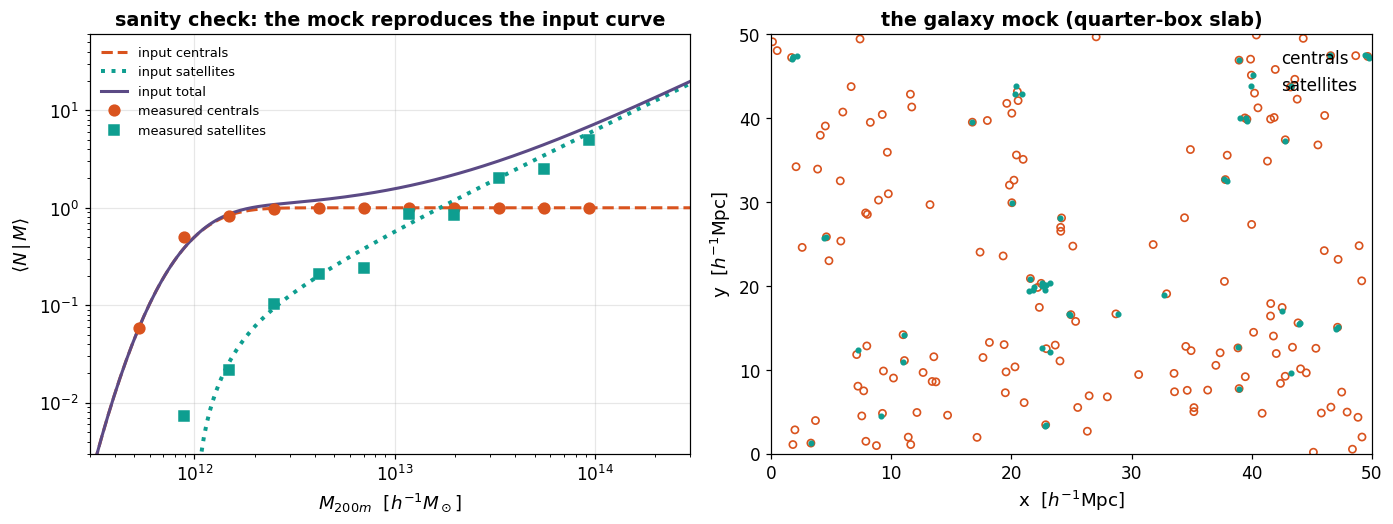

In [18]:
bins = np.geomspace(max(M_host[keep_host].min(), 1e11), M_host.max() * 1.05, 13)
ic = np.digitize(M_host, bins) - 1
mid, meas_c, meas_s = [], [], []
for k in range(len(bins) - 1):
    m = (ic == k) & keep_host
    if m.sum() < 3:
        continue
    inset = np.isin(ghost, np.where(m)[0])
    mid.append(np.sqrt(bins[k] * bins[k + 1]))
    meas_c.append((~is_sat[inset]).sum() / m.sum())
    meas_s.append(is_sat[inset].sum() / m.sum())

Mg = np.geomspace(1e11, 3e15, 300)
Nc, Ns = hod_mean(Mg, P)
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.9))
ax[0].loglog(Mg, Nc, "--", color=C_HALO, label="input centrals")
ax[0].loglog(Mg, Ns, ":", color=C_SAT, lw=2.6, label="input satellites")
ax[0].loglog(Mg, Nc + Ns, "-", color=C_ALT, label="input total")
ax[0].loglog(mid, meas_c, "o", color=C_HALO, ms=7, label="measured centrals")
ax[0].loglog(mid, meas_s, "s", color=C_SAT, ms=7, label="measured satellites")
ax[0].set(xlabel="$M_{200m}$  [$h^{-1}M_\\odot$]",
          ylabel="$\\langle N\\,|\\,M\\rangle$", xlim=(3e11, 3e14), ylim=(3e-3, 60),
          title="sanity check: the mock reproduces the input curve")
ax[0].legend(fontsize=8.5, loc="upper left")
slg = gpos[:, 2] < 0.25 * L
ax[1].scatter(gpos[slg & ~is_sat, 0], gpos[slg & ~is_sat, 1], s=22,
              facecolor="none", edgecolor=C_HALO, lw=1.1, label="centrals")
ax[1].scatter(gpos[slg & is_sat, 0], gpos[slg & is_sat, 1], s=9, c=C_SAT,
              label="satellites")
ax[1].set(xlabel="x  [$h^{-1}$Mpc]", ylabel="y  [$h^{-1}$Mpc]", xlim=(0, L),
          ylim=(0, L), title="the galaxy mock (quarter-box slab)")
ax[1].legend(loc="upper right")
ax[1].grid(False)
fig.tight_layout()
plt.show()

### Why the HOD earns its keep: clustering at matched number density

Two occupation models tuned to the **same** $n_{\rm gal}$ still predict different
clustering, because they distribute galaxies over differently-massive halos. That
difference is the signal HOD fitting exploits.

target number density 5.483e-03 h^3 Mpc^-3

baseline   $\alpha$=1.00             n=5.312e-03  f_sat=0.215  logMmin=12.000
satellite-heavy   $\alpha$=1.5       n=5.432e-03  f_sat=0.290  logMmin=12.080
satellite-light   $\alpha$=0.6       n=5.456e-03  f_sat=0.268  logMmin=12.045


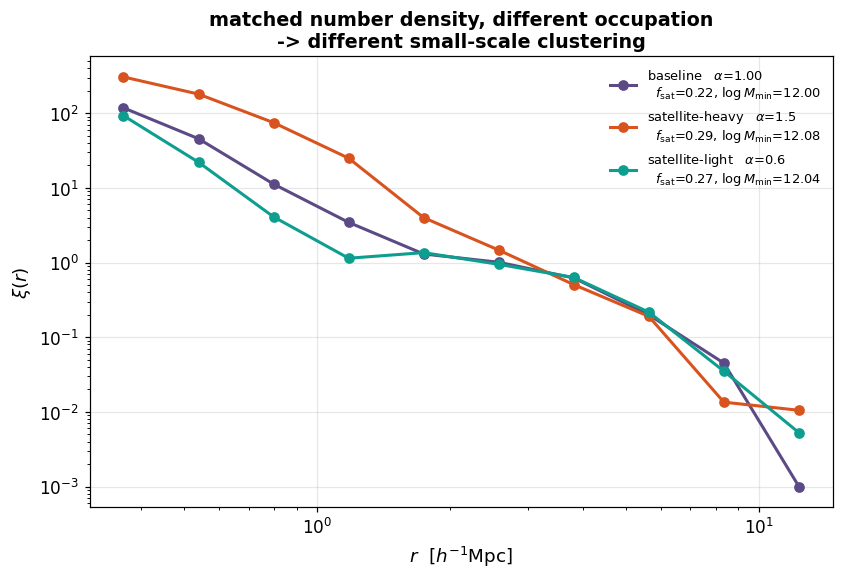


[total 188.4 s]


In [19]:
def xi_r(gp, L, bins):
    """Periodic two-point correlation function by direct pair counting."""
    t = cKDTree(gp % L, boxsize=L)
    cum = t.count_neighbors(t, bins, cumulative=True).astype(float)
    DD = np.diff(cum) / 2.0
    n = len(gp)
    RR = 0.5 * n * (n - 1) * (4 / 3 * np.pi * np.diff(bins ** 3)) / L ** 3
    return DD / RR - 1.0


def tune_to_density(p_base, target, key="logMmin", lo=11.0, hi=14.5):
    """Bisect one HOD parameter until the predicted n_gal matches the target."""
    p = dict(p_base)
    for _ in range(40):
        mid_ = 0.5 * (lo + hi)
        p[key] = mid_
        Nc, Ns = hod_mean(M_host[keep_host], p)
        if (Nc + Ns).sum() / L ** 3 > target:       # n_gal falls as logMmin rises
            lo = mid_
        else:
            hi = mid_
    p[key] = 0.5 * (lo + hi)
    return p


Nc0, Ns0 = hod_mean(M_host[keep_host], P)
target = (Nc0 + Ns0).sum() / L ** 3
rbins = np.geomspace(0.3, 15.0, 11)
rmid = np.sqrt(rbins[1:] * rbins[:-1])

variants = [(f"baseline   $\\alpha$={P['alpha']:.2f}", dict(P), C_ALT),
            ("satellite-heavy   $\\alpha$=1.5", dict(P, alpha=1.5), C_HALO),
            ("satellite-light   $\\alpha$=0.6", dict(P, alpha=0.6), C_SAT)]

fig, ax = plt.subplots(figsize=(7.8, 5.4))
print(f"target number density {target:.3e} h^3 Mpc^-3\n")
for lbl, pv, col in variants:
    pv = tune_to_density(pv, target)
    gp, gv, sat, _ = populate(M_host, ctr_peak, v_fof, pv, seed=11)
    xi = xi_r(gp, L, rbins)
    ax.loglog(rmid, np.maximum(xi, 1e-3), "o-", color=col,
              label=f"{lbl}\n  $f_{{\\rm sat}}$={sat.mean():.2f}, "
                    f"$\\log M_{{\\min}}$={pv['logMmin']:.2f}")
    print(f"{lbl:36s} n={len(gp) / L ** 3:.3e}  f_sat={sat.mean():.3f}  "
          f"logMmin={pv['logMmin']:.3f}")
ax.set(xlabel="$r$  [$h^{-1}$Mpc]", ylabel="$\\xi(r)$",
       title="matched number density, different occupation\n"
             "-> different small-scale clustering")
ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()
print(f"\n[total {time.time() - T0:.1f} s]")

## 7. Things to try

Each is a one-line edit to `P`, then re-run from section 2.

1. **Bridging on demand.** Push `filament_width` from 0.35 down to 0.15, then up to 0.6.
   At which value does `b = 0.2` start fusing neighbouring halos? You have just found
   that FoF's answer depends on the diffuse material *between* halos, not only on the
   halos themselves.

2. **Break the pair.** Raise `pair_sep_frac` until `b = 0.35` no longer merges the
   planted pair. Then set `pair_vrel = 200` and re-run section 4: what happens to the
   "separation in units of sigma" number, and can the 6-D finder still split it?

3. **Resolution.** Try `n_side = 48`, then `80`. The particle mass changes, so
   `n_min_halo = 20` now means a different physical mass. Which mass estimator in
   section 5 degrades fastest at low particle count?

4. **Threshold ordering.** Add `("100m", 100, "mean")` and `("2500c", 2500, "crit")` to
   `P["deltas"]`. Confirm the ordering of the recovered masses and explain the sign.

5. **Centre matters.** Section 5 measures the same halos from a mean-position centre and
   from a density peak. Which $\Delta$ is most sensitive to the choice, and why is it the
   highest one?

6. **HOD degeneracy.** Raise `sigma_logM` from 0.25 to 0.80 while `tune_to_density`
   holds $n_{\rm gal}$ fixed. The occupation curve changes shape but $\xi$ barely moves
   on large scales. Which scales *do* respond, and what does that imply for fitting real
   data?

7. **Bring your own snapshot.** Replace `pos`, `vel`, `M_P`, `L` at the end of section 2
   with a real simulation and re-run sections 3-6. Only the ground-truth comparisons
   (`hid`, `M_true`, `n_part_true`) need to be dropped.